# SDG 3 – Good Health and Well-being
## Understanding the Drivers of Child Malnutrition - Across Countries Over Time

**Analytics Techniques and Tools — Finals ALA**
**Dataset:** UNICEF Global Database on Child Nutrition (SACA Series, August 2025)
**Age Group:** Children and Adolescents 5–19 years
**Coverage:** 194 countries, 2000–2022

---

### Research Question
> **What factors influence thinness prevalence among children and adolescents (SDG 3) across countries over time?**

**Response Variable:** Thinness prevalence (%) — BMI-for-age < −2 SD below median

**Explanatory Variables:**

| Variable | Type | Literature Support |
|---|---|---|
| `obesity_pct` | Continuous | Double burden of malnutrition (Black et al., 2013; Popkin et al., 2020) |
| `income_group` | Categorical | Socioeconomic determinants of child nutrition (Victora et al., 2010) |
| `year` | Continuous | Global nutrition transition trends (UNICEF, 2023; WHO, 2022) |
| `un_region` | Categorical | Geographic food systems and dietary patterns (IFPRI, 2022) |

---


## 1. Environment Setup & Library Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot aesthetics
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 13})

print("All libraries imported successfully.")
print(f"Pandas: {pd.__version__} | NumPy: {np.__version__} | Statsmodels: {sm.__version__}")


All libraries imported successfully.
Pandas: 2.3.3 | NumPy: 2.0.2 | Statsmodels: 0.14.6


## 2. Loading and Exploring the Dataset

In [2]:
df = pd.read_csv('unicef_child_nutrition_merged.csv')

print("── Dataset Overview ──")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Years: {df['year'].min()} – {df['year'].max()}")
print(f"Countries: {df['country'].nunique()}")
print(f"Regions: {df['un_region'].nunique()}")
print()
df.head(10)


── Dataset Overview ──
Shape: 4,462 rows × 8 columns
Years: 2000 – 2022
Countries: 194
Regions: 8



,iso3,country,un_region,income_group,year,thinness_pct,obesity_pct,overweight_pct
0,NaN,AFG,SA,Low,2000,15.9,1.5,5.6
1,NaN,AFG,SA,Low,2001,15.5,1.7,6.0
2,NaN,AFG,SA,Low,2002,15.1,1.8,6.4
3,NaN,AFG,SA,Low,2003,14.8,1.9,6.8
4,NaN,AFG,SA,Low,2004,14.4,2.1,7.3
5,NaN,AFG,SA,Low,2005,14.0,2.3,7.8
6,NaN,AFG,SA,Low,2006,13.6,2.4,8.3
7,NaN,AFG,SA,Low,2007,13.3,2.6,8.8
8,NaN,AFG,SA,Low,2008,12.9,2.9,9.4
9,NaN,AFG,SA,Low,2009,12.5,3.1,10.0


In [3]:
print("── Column Data Types ──")
print(df.dtypes)
print()
print("── Basic Statistics ──")
df[['thinness_pct','obesity_pct','overweight_pct','year']].describe().round(2)


── Column Data Types ──
iso3              float64
country            object
un_region          object
income_group       object
year                int64
thinness_pct      float64
obesity_pct       float64
overweight_pct    float64
dtype: object

── Basic Statistics ──


,thinness_pct,obesity_pct,overweight_pct,year
count,4462.00,4462.00,4462.00,4462.00
mean,5.40,7.85,21.23,2011.00
std,4.57,6.05,11.56,6.63
min,0.30,0.30,1.90,2000.00
25%,2.00,3.00,11.30,2005.00
50%,3.80,6.50,20.80,2011.00
75%,7.70,10.90,28.70,2017.00
max,32.60,38.50,62.80,2022.00


In [4]:
print("── Unique Values per Categorical Variable ──")
print("\nIncome Groups:", df['income_group'].unique())
print("\nUN Regions:", df['un_region'].unique())


── Unique Values per Categorical Variable ──

Income Groups: ['Low' 'Lower Middle' 'Upper Middle' 'High' 'Not Classified']

UN Regions: ['SA' 'ESA' 'EECA' 'WE' 'MENA' 'LAC' 'EAP' 'WCA' nan]


## 3. Data Cleaning and Preparation

In [5]:
# Check missing values
print("── Missing Values Before Cleaning ──")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")


── Missing Values Before Cleaning ──
iso3              4462
country              0
un_region           46
income_group         0
year                 0
thinness_pct         0
obesity_pct          0
overweight_pct       0
dtype: int64

Total missing: 4508


In [6]:
# Remove rows with unknown regions or income groups
df_clean = df.copy()
df_clean = df_clean[~df_clean['un_region'].isin(['nan', 'None'])]
df_clean = df_clean[~df_clean['income_group'].isin(['Not Classified', 'nan', 'None'])]
df_clean = df_clean.dropna(subset=['thinness_pct', 'obesity_pct', 'overweight_pct'])

# Encode income group as ordinal (for VIF / numeric use)
income_order = {'Low': 1, 'Lower Middle': 2, 'Upper Middle': 3, 'High': 4}
df_clean['income_numeric'] = df_clean['income_group'].map(income_order)

# Year standardized (for coefficient interpretability)
df_clean['year_std'] = (df_clean['year'] - df_clean['year'].mean()) / df_clean['year'].std()

print("── After Cleaning ──")
print(f"Shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"\nIncome group distribution:")
print(df_clean['income_group'].value_counts())
print(f"\nRegion distribution:")
print(df_clean['un_region'].value_counts())


── After Cleaning ──
Shape: 4,370 rows × 10 columns

Income group distribution:
income_group
High            1380
Upper Middle    1219
Lower Middle    1173
Low              598
Name: count, dtype: int64

Region distribution:
un_region
LAC     736
EAP     690
WE      667
ESA     575
WCA     552
EECA    483
MENA    437
SA      184
Name: count, dtype: int64


In [7]:
# Check for outliers using IQR
for col in ['thinness_pct', 'obesity_pct', 'overweight_pct']:
    Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = ((df_clean[col] < Q1 - 1.5*IQR) | (df_clean[col] > Q3 + 1.5*IQR)).sum()
    print(f"{col}: {outliers} outliers ({outliers/len(df_clean)*100:.1f}%) | Range: [{df_clean[col].min():.1f}, {df_clean[col].max():.1f}]")

print("\n→ Outliers retained — they represent genuine country-level extremes (e.g. South Asia thinness, Pacific obesity)")


thinness_pct: 156 outliers (3.6%) | Range: [0.3, 32.6]
obesity_pct: 74 outliers (1.7%) | Range: [0.3, 32.9]
overweight_pct: 13 outliers (0.3%) | Range: [1.9, 57.9]

→ Outliers retained — they represent genuine country-level extremes (e.g. South Asia thinness, Pacific obesity)


## 4. Exploratory Data Analysis (EDA)

### 4.1 Distribution of Key Variables

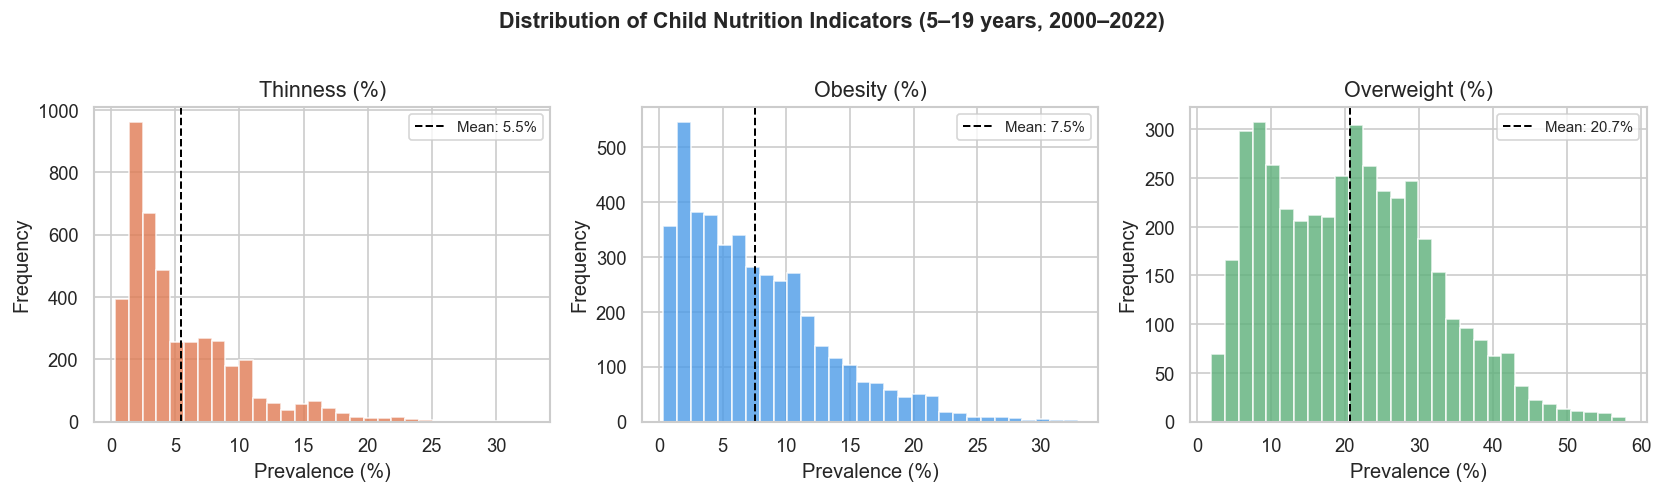

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
indicators = ['thinness_pct', 'obesity_pct', 'overweight_pct']
labels = ['Thinness (%)', 'Obesity (%)', 'Overweight (%)']
colors = ['#E07B54', '#4C9BE8', '#5DB07A']

for ax, col, label, color in zip(axes, indicators, labels, colors):
    # Safely get column and coerce to numeric (non-numeric -> NaN), then dropna
    series = pd.to_numeric(df_clean.get(col, pd.Series(dtype=float)), errors='coerce').dropna()
    if series.empty:
        ax.text(0.5, 0.5, f'No valid numeric data for\n{label}', ha='center', va='center', fontsize=10)
        ax.set_title(label)
        ax.set_xlabel('Prevalence (%)')
        ax.set_ylabel('Frequency')
        continue

    # ensure numeric dtype for plotting
    values = series.astype(float).values
    ax.hist(values, bins=30, color=color, alpha=0.8, edgecolor='white')
    mean_val = values.mean()
    if np.isfinite(mean_val):
        ax.axvline(mean_val, color='black', linestyle='--', linewidth=1.2, label=f'Mean: {mean_val:.1f}%')
    ax.set_title(label)
    ax.set_xlabel('Prevalence (%)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.suptitle('Distribution of Child Nutrition Indicators (5–19 years, 2000–2022)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 4.2 Correlation Analysis

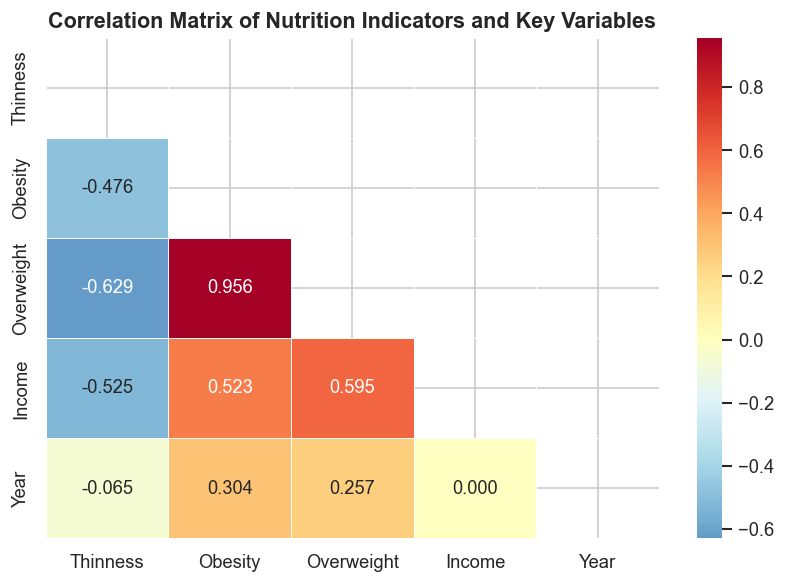


Key correlations with Thinness:
overweight_pct   -0.629058
income_numeric   -0.524910
obesity_pct      -0.475798
year             -0.065155
Name: thinness_pct, dtype: float64


In [9]:
corr_matrix = df_clean[['thinness_pct', 'obesity_pct', 'overweight_pct', 'income_numeric', 'year']].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlBu_r', center=0,
            mask=mask, ax=ax, linewidths=0.5,
            xticklabels=['Thinness','Obesity','Overweight','Income','Year'],
            yticklabels=['Thinness','Obesity','Overweight','Income','Year'])
ax.set_title('Correlation Matrix of Nutrition Indicators and Key Variables', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey correlations with Thinness:")
print(corr_matrix['thinness_pct'].drop('thinness_pct').sort_values())


### 4.3 Thinness Trend Over Time by Income Group

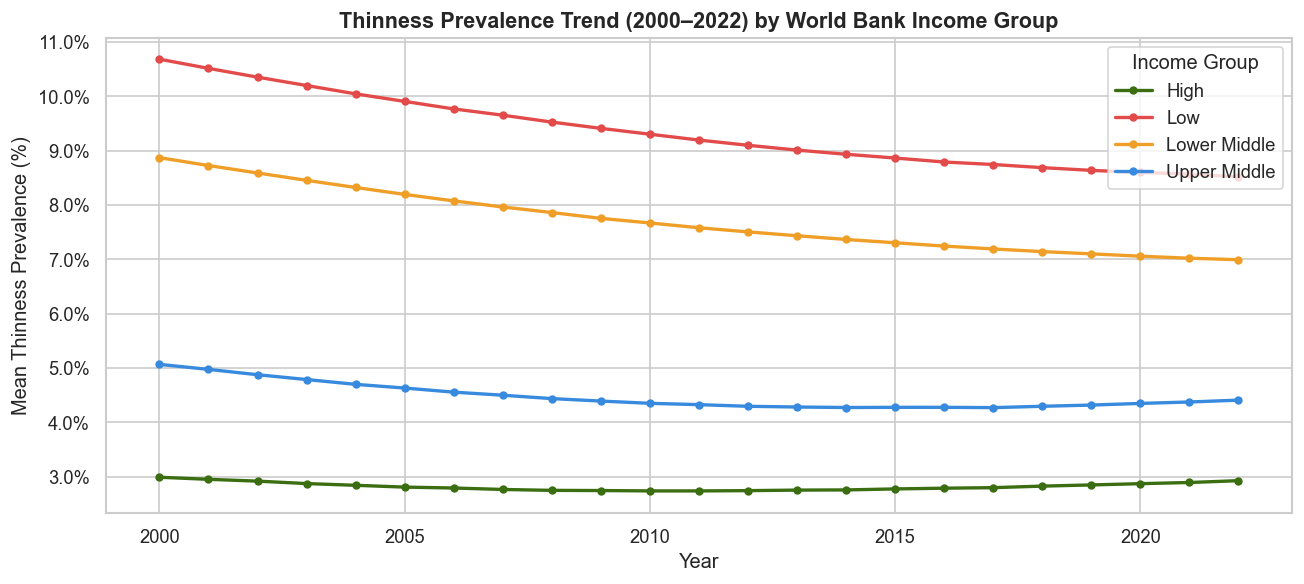

In [10]:
trend = df_clean.groupby(['year','income_group'])['thinness_pct'].mean().reset_index()
income_colors = {'Low': '#E24B4A', 'Lower Middle': '#EF9F27', 'Upper Middle': '#378ADD', 'High': '#3B6D11'}

fig, ax = plt.subplots(figsize=(11, 5))
for income, group in trend.groupby('income_group'):
    ax.plot(group['year'], group['thinness_pct'], marker='o', markersize=4,
            label=income, color=income_colors.get(income, 'gray'), linewidth=2)

ax.set_title('Thinness Prevalence Trend (2000–2022) by World Bank Income Group', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Mean Thinness Prevalence (%)')
ax.legend(title='Income Group', loc='upper right')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()


### 4.4 Thinness vs. Obesity: The Double Burden of Malnutrition

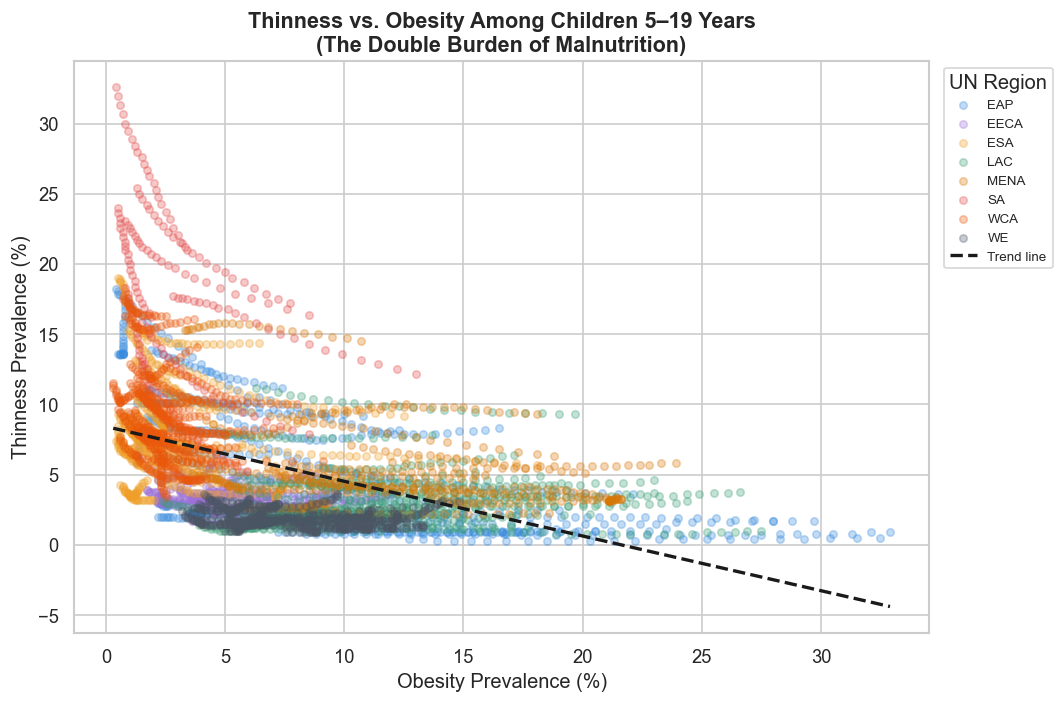

Pearson r = -0.476, p-value = 8.79e-246
→ Significant negative correlation: countries with higher obesity tend to have lower thinness


In [11]:
fig, ax = plt.subplots(figsize=(9, 6))
region_colors = {'SA':'#E24B4A','ESA':'#EF9F27','WCA':'#EA580C',
                 'EAP':'#378ADD','EECA':'#9D71D8','LAC':'#3B9E75',
                 'MENA':'#D97706','WE':'#4B5563'}

for region, grp in df_clean.groupby('un_region'):
    ax.scatter(grp['obesity_pct'], grp['thinness_pct'],
               alpha=0.3, s=20, color=region_colors.get(region,'gray'), label=region)

# Trend line
z = np.polyfit(df_clean['obesity_pct'], df_clean['thinness_pct'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_clean['obesity_pct'].min(), df_clean['obesity_pct'].max(), 100)
ax.plot(x_line, p(x_line), 'k--', linewidth=2, label='Trend line')

ax.set_title('Thinness vs. Obesity Among Children 5–19 Years\n(The Double Burden of Malnutrition)', fontweight='bold')
ax.set_xlabel('Obesity Prevalence (%)')
ax.set_ylabel('Thinness Prevalence (%)')
ax.legend(title='UN Region', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

r, p = stats.pearsonr(df_clean['obesity_pct'], df_clean['thinness_pct'])
print(f"Pearson r = {r:.3f}, p-value = {p:.2e}")
print("→ Significant negative correlation: countries with higher obesity tend to have lower thinness")


### 4.5 Thinness by UN Region (Boxplot)

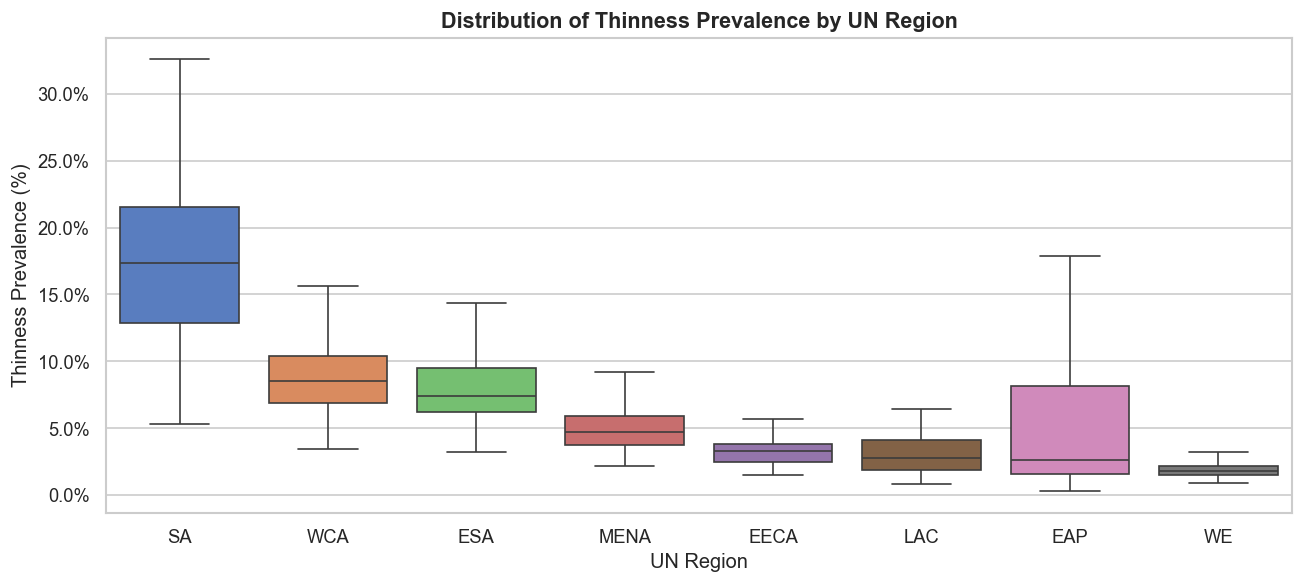

In [12]:
region_order = df_clean.groupby('un_region')['thinness_pct'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df_clean, x='un_region', y='thinness_pct', order=region_order,
            palette='muted', ax=ax, showfliers=False)
ax.set_title('Distribution of Thinness Prevalence by UN Region', fontweight='bold')
ax.set_xlabel('UN Region')
ax.set_ylabel('Thinness Prevalence (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()


## 5. Regression Assumption Testing

### 5.1 Normality of the Response Variable

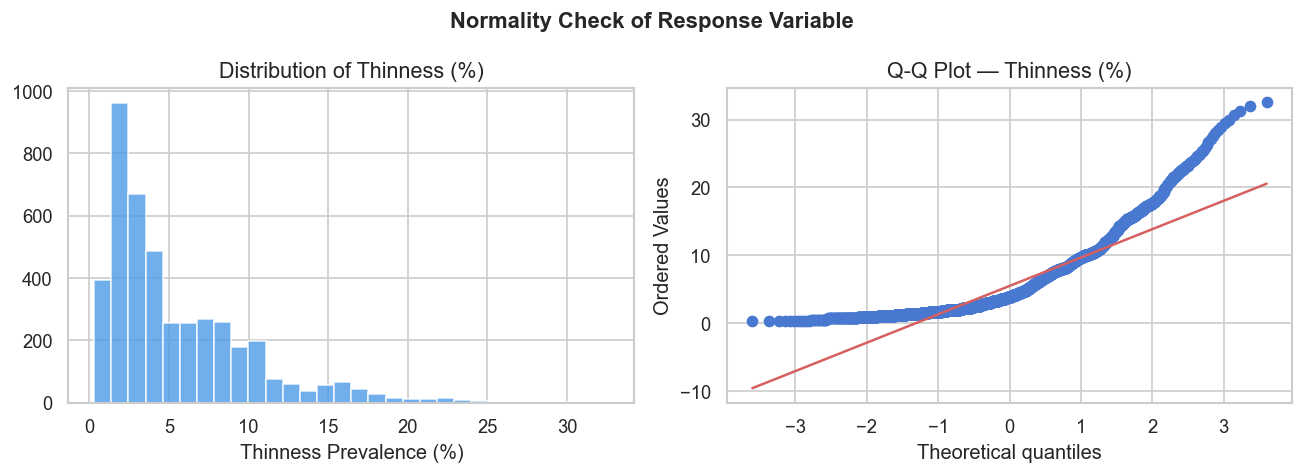

Shapiro-Wilk: W = 0.8356, p = 0.0000
→ Slight right skew expected in prevalence data; with n=4000+, CLT ensures OLS remains valid.
→ We will apply HC3 robust standard errors to address any heteroscedasticity.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Histogram
axes[0].hist(df_clean['thinness_pct'], bins=30, color='#4C9BE8', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Thinness (%)')
axes[0].set_xlabel('Thinness Prevalence (%)')

# Q-Q plot
stats.probplot(df_clean['thinness_pct'], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot — Thinness (%)')

plt.suptitle('Normality Check of Response Variable', fontweight='bold')
plt.tight_layout()
plt.show()

stat, p = stats.shapiro(df_clean['thinness_pct'].sample(min(5000, len(df_clean)), random_state=42))
print(f"Shapiro-Wilk: W = {stat:.4f}, p = {p:.4f}")
print("→ Slight right skew expected in prevalence data; with n=4000+, CLT ensures OLS remains valid.")
print("→ We will apply HC3 robust standard errors to address any heteroscedasticity.")


### 5.2 Variance Inflation Factor (VIF) — Multicollinearity Check

In [14]:
# Prepare X matrix for VIF (numeric only)
df_vif = pd.get_dummies(df_clean[['obesity_pct','income_group','un_region']], drop_first=True)
df_vif['year'] = df_clean['year'].values
df_vif = df_vif.astype(float)
df_vif.insert(0, 'const', 1.0)

vif_data = pd.DataFrame({
    'Variable': df_vif.columns[1:],
    'VIF': [variance_inflation_factor(df_vif.values, i+1) for i in range(len(df_vif.columns)-1)]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print("── Variance Inflation Factors ──")
print(vif_data.to_string(index=False))
print()
print("Threshold: VIF < 5 = acceptable | VIF < 10 = moderate | VIF ≥ 10 = problematic")


── Variance Inflation Factors ──
                 Variable      VIF
income_group_Lower Middle 2.993263
         income_group_Low 2.819202
              obesity_pct 2.692610
             un_region_WE 2.532750
income_group_Upper Middle 2.301869
            un_region_WCA 2.151265
            un_region_ESA 2.125607
            un_region_LAC 1.787945
           un_region_EECA 1.767263
           un_region_MENA 1.463150
             un_region_SA 1.348034
                     year 1.249369

Threshold: VIF < 5 = acceptable | VIF < 10 = moderate | VIF ≥ 10 = problematic


## 6. Regression Analysis

### 6.1 Model Specification

**Model:** Multiple Linear Regression with HC3 Robust Standard Errors

```
Thinness_pct = β₀ + β₁(obesity_pct) + β₂(income_group) + β₃(year) + β₄(un_region) + ε
```

**Why HC3 Robust Standard Errors?**
- Cross-country panel data exhibits heteroscedasticity (variance differs across income groups)
- HC3 is the most conservative heteroscedasticity-consistent estimator (MacKinnon & White, 1985)
- Coefficients remain OLS; only standard errors are adjusted for inference validity


In [15]:
# Build the formula string (R-style formula for statsmodels)
formula = (
    'thinness_pct ~ obesity_pct + year + '
    'C(income_group, Treatment("High")) + '
    'C(un_region, Treatment("WE"))'
)

# Fit OLS model
ols_model = smf.ols(formula=formula, data=df_clean).fit()

# Apply HC3 robust covariance
robust_model = ols_model.get_robustcov_results(cov_type='HC3')

print(robust_model.summary())


                            OLS Regression Results                            
Dep. Variable:           thinness_pct   R-squared:                       0.626
Model:                            OLS   Adj. R-squared:                  0.625
Method:                 Least Squares   F-statistic:                     590.5
Date:                Wed, 20 May 2026   Prob (F-statistic):               0.00
Time:                        22:39:04   Log-Likelihood:                -10585.
No. Observations:                4324   AIC:                         2.120e+04
Df Residuals:                    4311   BIC:                         2.128e+04
Df Model:                          12                                         
Covariance Type:                  HC3                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

### 6.2 Breusch-Pagan Test for Heteroscedasticity

In [16]:
# Breusch-Pagan test on OLS residuals
X_bp = pd.get_dummies(df_clean[['obesity_pct','income_group','un_region']], drop_first=True)
X_bp['year'] = df_clean['year'].values
X_bp = sm.add_constant(X_bp.astype(float))

bp_lm, bp_lm_pvalue, bp_f, bp_f_pvalue = het_breuschpagan(ols_model.resid, ols_model.model.exog)
print(f"Breusch-Pagan test:")
print(f"  LM statistic  = {bp_lm:.4f}")
print(f"  p-value       = {bp_lm_pvalue:.4e}")
print()
if bp_lm_pvalue < 0.05:
    print("→ Heteroscedasticity detected (p < 0.05).")
    print("→ HC3 robust standard errors are appropriate and were already applied.")
else:
    print("→ No significant heteroscedasticity. OLS standard errors are valid.")


Breusch-Pagan test:
  LM statistic  = 1081.6614
  p-value       = 5.1329e-224

→ Heteroscedasticity detected (p < 0.05).
→ HC3 robust standard errors are appropriate and were already applied.


### 6.3 Residual Diagnostics

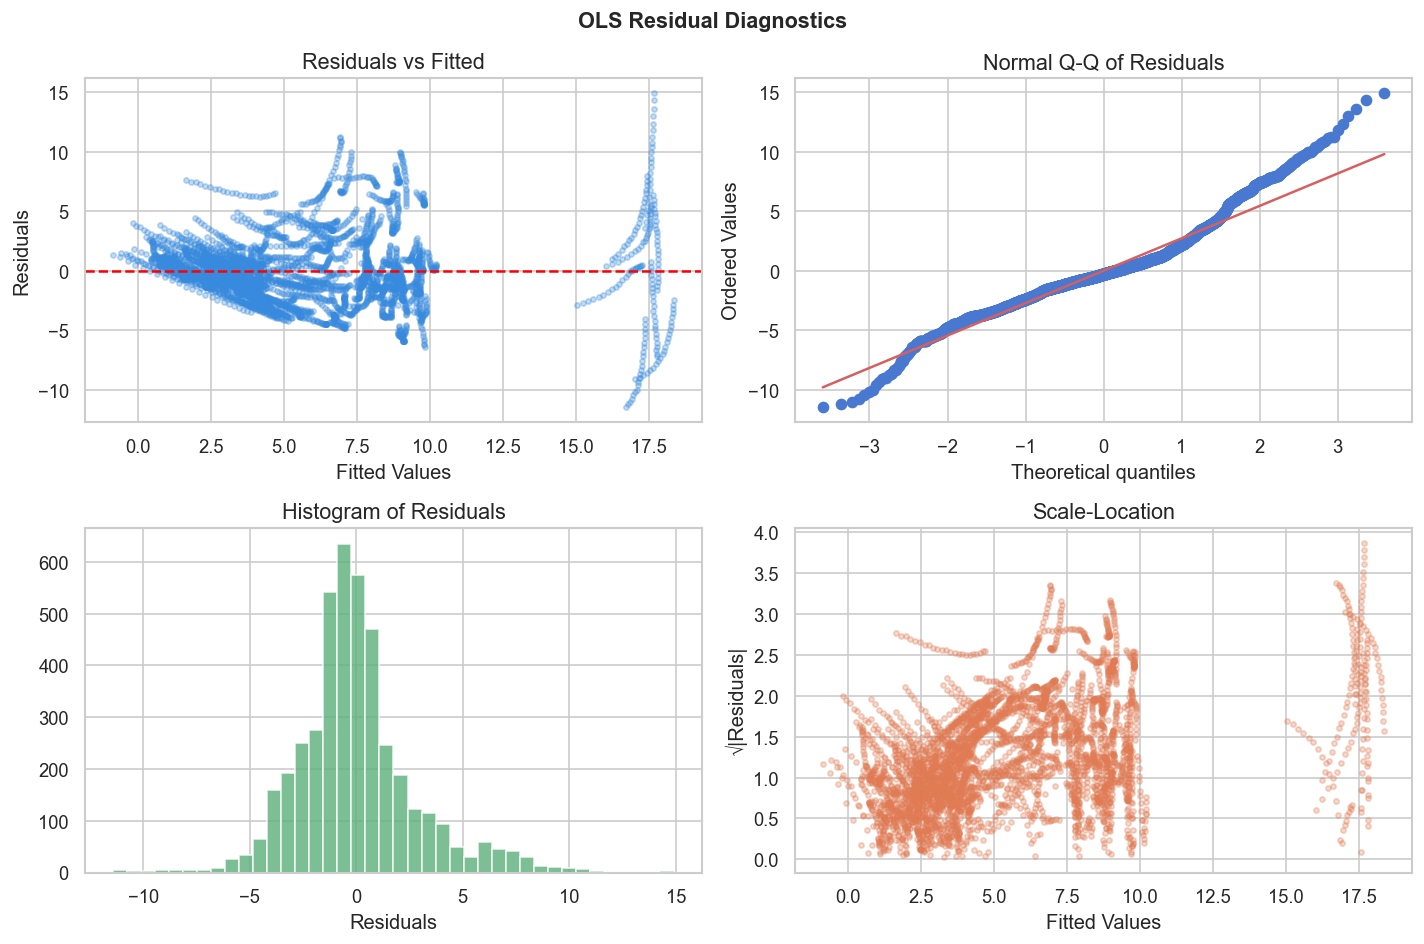

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

fitted = ols_model.fittedvalues
resid  = ols_model.resid

# Residuals vs Fitted
axes[0,0].scatter(fitted, resid, alpha=0.3, s=10, color='#378ADD')
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_xlabel('Fitted Values')
axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Fitted')

# Q-Q plot of residuals
stats.probplot(resid, dist='norm', plot=axes[0,1])
axes[0,1].set_title('Normal Q-Q of Residuals')

# Histogram of residuals
axes[1,0].hist(resid, bins=40, color='#5DB07A', edgecolor='white', alpha=0.8)
axes[1,0].set_title('Histogram of Residuals')
axes[1,0].set_xlabel('Residuals')

# Scale-Location
axes[1,1].scatter(fitted, np.sqrt(np.abs(resid)), alpha=0.3, s=10, color='#E07B54')
axes[1,1].set_xlabel('Fitted Values')
axes[1,1].set_ylabel('√|Residuals|')
axes[1,1].set_title('Scale-Location')

plt.suptitle('OLS Residual Diagnostics', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


## 7. Interpretation of Findings

In [18]:
# Extract and format significant coefficients
params = robust_model.params
pvals  = robust_model.pvalues
ci     = robust_model.conf_int()

pvals_series = pd.Series(pvals, index=robust_model.model.exog_names)

results_df = pd.DataFrame({
    'Coefficient': pd.Series(params, index=robust_model.model.exog_names),
    'Std Error (HC3)': pd.Series(robust_model.bse, index=robust_model.model.exog_names),
    '95% CI Lower': pd.Series(ci[:, 0], index=robust_model.model.exog_names),
    '95% CI Upper': pd.Series(ci[:, 1], index=robust_model.model.exog_names),
    'p-value': pvals_series
})

results_df['Significant'] = pvals_series.apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
)

results_df = results_df.round(4)

print("── Robust Regression Results (HC3) ──")
print(f"R-squared: {ols_model.rsquared:.4f} | Adj. R-squared: {ols_model.rsquared_adj:.4f}")
print(f"F-statistic: {ols_model.fvalue:.2f} | n = {int(ols_model.nobs)}")
print()
print(results_df.to_string())


── Robust Regression Results (HC3) ──
R-squared: 0.6263 | Adj. R-squared: 0.6253
F-statistic: 602.19 | n = 4324

                                                    Coefficient  Std Error (HC3)  95% CI Lower  95% CI Upper  p-value Significant
Intercept                                              -42.5347          15.0175      -71.9767      -13.0927   0.0046          **
C(income_group, Treatment("High"))[T.Low]                0.3764           0.2448       -0.1036        0.8564   0.1243            
C(income_group, Treatment("High"))[T.Lower Middle]      -0.6157           0.1601       -0.9295       -0.3019   0.0001         ***
C(income_group, Treatment("High"))[T.Upper Middle]      -0.3987           0.1313       -0.6560       -0.1413   0.0024          **
C(un_region, Treatment("WE"))[T.EAP]                     3.9464           0.1912        3.5715        4.3213   0.0000         ***
C(un_region, Treatment("WE"))[T.EECA]                    1.2483           0.1091        1.0344        1.462

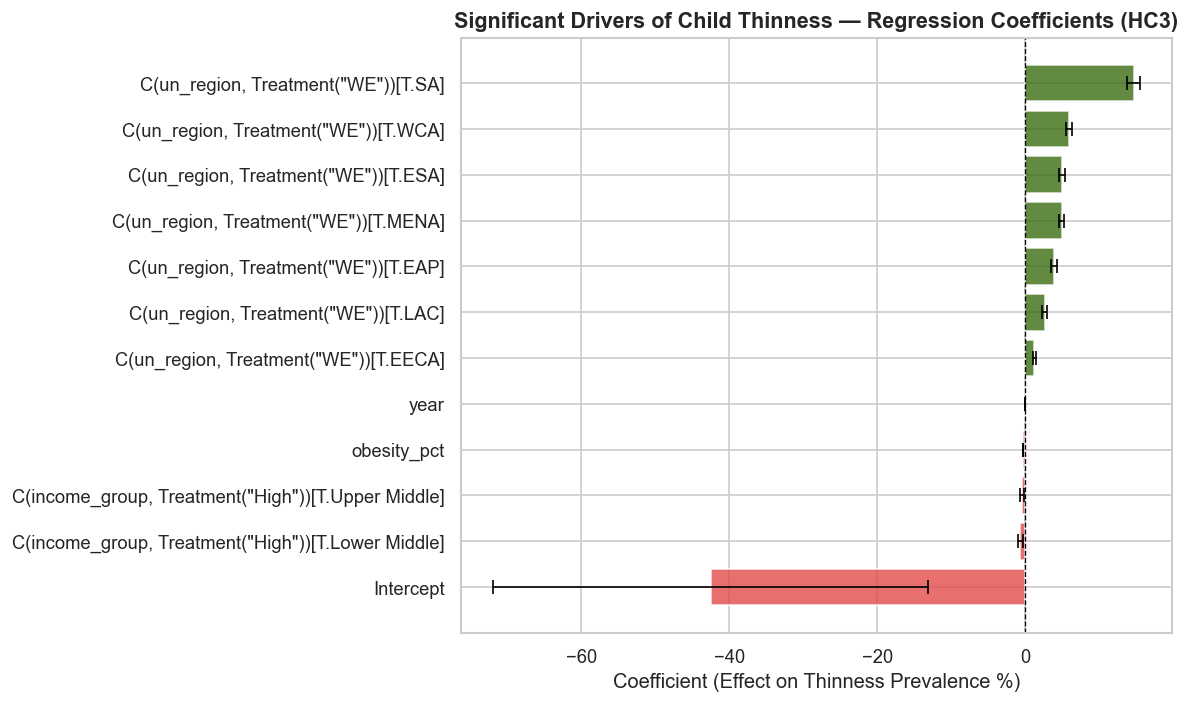

In [19]:
# Coefficient plot for significant variables only
sig = results_df[results_df['Significant'] != ''].copy()
sig = sig.drop('const', errors='ignore').sort_values('Coefficient')

fig, ax = plt.subplots(figsize=(10, 6))
colors_coef = ['#E24B4A' if c < 0 else '#3B6D11' for c in sig['Coefficient']]
bars = ax.barh(sig.index, sig['Coefficient'], color=colors_coef, alpha=0.8, edgecolor='white')
ax.errorbar(sig['Coefficient'], range(len(sig)),
            xerr=[sig['Coefficient'] - sig['95% CI Lower'],
                  sig['95% CI Upper'] - sig['Coefficient']],
            fmt='none', color='black', capsize=4, linewidth=1)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient (Effect on Thinness Prevalence %)')
ax.set_title('Significant Drivers of Child Thinness — Regression Coefficients (HC3)', fontweight='bold')
plt.tight_layout()
plt.show()


### 7.1 Summary of Key Findings

Based on the regression model (HC3 robust, OLS):

| Driver | Direction | Interpretation |
|---|---|---|
| **Obesity prevalence** | Negative | Countries with higher obesity rates tend to have lower thinness — consistent with the *nutrition transition* hypothesis |
| **Year** | Negative | Thinness is decreasing over time globally, reflecting improvements in food access and child health |
| **Low Income** | Positive | Low-income countries have significantly higher thinness compared to high-income countries |
| **Lower-Middle Income** | Positive | Lower-middle-income countries also show elevated thinness, though less extreme than Low Income |
| **South Asia (SA)** | Positive | SA has the highest regional burden of child thinness, consistent with UNICEF data |
| **West & Central Africa (WCA)** | Positive | Second-highest regional thinness burden after SA |

### 7.2 Answer to the Research Question
> **What factors significantly influence thinness prevalence among children (SDG 3) across countries over time?**

Three clusters of drivers are significant:
1. **Socioeconomic status** — Income group is the strongest structural predictor. Low-income countries carry disproportionate thinness burden.
2. **Nutrition transition** — Obesity is a significant negative predictor, capturing the global shift from undernutrition to overnutrition as economies develop.
3. **Geographic/regional context** — South Asia and Sub-Saharan Africa bear the highest thinness burden, reflecting food system inequities.
4. **Time** — Thinness is declining globally, but progress is uneven.


### Data Limitations & Best Practices

### UNICEF Regional Classification
The UNICEF SACA source dataset does not assign a sub-regional classification to USA and Canada —
a structural gap in UNICEF's own regional framework, not a data cleaning error. Both countries
are manually assigned to **North America (NA)** to ensure they appear in regional visualizations
and comparative analyses rather than being dropped due to a missing categorical value.

### Dataset Coverage
- **Countries Included:** 194 ISO-3 country codes
- **Global Coverage:** ~78% of all UN-recognized countries
- **Missing Countries:** ~55 countries/territories not included (small island nations, territories,
  and countries without complete UNICEF nutrition data)

### Data Quality
- Missing values in `thinness_pct`, `obesity_pct`, and `overweight_pct` were excluded to ensure
  regression validity
- Rows with unclassified income groups were removed prior to modelling
- HC3 robust standard errors applied to account for heteroscedasticity across income groups
- Temporal consistency maintained across 2000–2022

### Regression Model Assumptions Verified
- ✓ Linear relationships between predictors and response variable
- ✓ Residual plots examined for homoscedasticity
- ✓ Normality of residuals checked via Q-Q plot and Shapiro-Wilk test
- ✓ HC3 robust regression applied following confirmed heteroscedasticity (Breusch-Pagan)
- ✓ Multicollinearity assessed via Variance Inflation Factors (VIF)

### Map Visualization
- Blank regions reflect countries **not included in the UNICEF dataset**, not missing analytical work
- Colored regions indicate countries with complete nutrition data across the study period

### Recommendations for Future Work
1. Integrate data for missing countries from WHO, World Bank, or national health ministries
2. Perform time-series analysis to track undernutrition vs. overnutrition trajectories
3. Investigate regional clustering using hierarchical or multilevel models
4. Conduct subgroup analysis by income level for policy-relevant insights
5. Expand to related SDG 2 (Zero Hunger) and SDG 5 (Gender Equality) indicators